# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 3: Modelling the Neuron — MCP, Perceptron & Its Limitations

---

In [ ]:
# Install / verify libraries (safe to run on Google Colab)
!pip install numpy matplotlib pandas -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, os

np.random.seed(42)
print("Libraries ready.")

Libraries ready.


---
## Section 3 — MCP (McCulloch-Pitts) Neurons
---

The MCP neuron works in three steps:
1. **Aggregate** — sum all binary inputs.
2. **Inhibition check** — if any inhibitory input is active, output = 0.
3. **Threshold** — output 1 if sum ≥ T, else 0.

### Task 1 — Implement MCP Neurons for AND and OR

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements the AND Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): Array of binary values (input 1).
        X2 (list): Array of binary values (input 2).
        T  (int) : Threshold value.  For AND, T = 2.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.

    Logic:
        g(X) = X1[i] + X2[i]   (element-wise sum)
        output = 1 if g(X) >= T else 0
    """
    assert len(X1) == len(X2), "Input arrays must have the same length."

    # Step 1 — Element-wise sum of the two inputs
    input_sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 — Apply threshold
    state_neuron = []
    for s in input_sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# ── AND Test ──────────────────────────────────────────────────────────────────
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # Both inputs must be 1 for AND to fire

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate  |  X1={X1}  X2={X2}  T={T}")
print(f"Output   : {result_and}")
print(f"Expected : [0, 0, 0, 1]\n")

# Truth table display
print("Truth Table — AND")
print("-" * 25)
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
for x1, x2, out in zip(X1, X2, result_and):
    print(f"{x1:>4} {x2:>4} {out:>8}")

AND gate  |  X1=[0, 0, 1, 1]  X2=[0, 1, 0, 1]  T=2
Output   : [0, 0, 0, 1]
Expected : [0, 0, 0, 1]

Truth Table — AND
-------------------------
  X1   X2   Output
   0    0        0
   0    1        0
   1    0        0
   1    1        1


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements the OR Boolean function using an MCP Neuron.

    Arguments:
        X1 (list): Array of binary values (input 1).
        X2 (list): Array of binary values (input 2).
        T  (int) : Threshold value.  For OR, T = 1.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.

    Logic:
        g(X) = X1[i] + X2[i]   (element-wise sum)
        output = 1 if g(X) >= T else 0
    """
    assert len(X1) == len(X2), "Input arrays must have the same length."

    # Step 1 — Element-wise sum
    input_sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 — Apply threshold (T=1 means at least one input must be 1)
    state_neuron = []
    for s in input_sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
# ── OR Test ───────────────────────────────────────────────────────────────────
T_or = 1   # At least one input must be 1 for OR to fire

result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"OR gate   |  X1={X1}  X2={X2}  T={T_or}")
print(f"Output   : {result_or}")
print(f"Expected : [0, 1, 1, 1]\n")

print("Truth Table — OR")
print("-" * 25)
print(f"{'X1':>4} {'X2':>4} {'Output':>8}")
for x1, x2, out in zip(X1, X2, result_or):
    print(f"{x1:>4} {x2:>4} {out:>8}")

OR gate   |  X1=[0, 0, 1, 1]  X2=[0, 1, 0, 1]  T=1
Output   : [0, 1, 1, 1]
Expected : [0, 1, 1, 1]

Truth Table — OR
-------------------------
  X1   X2   Output
   0    0        0
   0    1        1
   1    0        1
   1    1        1


---
### Section 3 — Questions

**Question 1 — List all limitations of the MCP Neuron:**

> 1. **Fixed, hand-crafted weights** — The MCP neuron has no learning mechanism. Weights (which are simply ±1 or inhibitory flags) and the threshold must be set manually by the designer. It cannot adapt from data.
>
> 2. **Binary inputs only** — The model only accepts inputs from {0, 1}. It cannot handle real-valued or continuous inputs, making it unsuitable for most real-world problems without heavy pre-processing.
>
> 3. **Fixed threshold** — The threshold T is a hyperparameter that must be chosen manually for each task. There is no mechanism to learn or tune it automatically.
>
> 4. **No learning algorithm** — Unlike the Perceptron or neural networks, the MCP neuron has no training procedure. It cannot improve by observing data.
>
> 5. **Cannot model non-linearly separable functions** — Just like a single perceptron, an MCP neuron can only represent linearly separable Boolean functions (AND, OR, NOT). It cannot represent XOR without combining multiple neurons.
>
> 6. **All inputs treated equally (unweighted)** — In the basic MCP model, every excitatory input contributes equally to the sum. Real biological neurons have synapses of varying strengths.
>
> 7. **Biologically oversimplified** — The model ignores time, firing rates, refractory periods, and many other properties of real neurons. It is a binary abstraction, not a realistic neuroscientific model.

---

**Question 2 — Can XOR be solved with a single MCP Neuron?**

> **Short answer: No**, a single MCP neuron cannot solve XOR, because XOR is **not linearly separable**.
>
> XOR truth table:
>
> | X1 | X2 | XOR |
> |----|----|-----|
> |  0 |  0 |  0  |
> |  0 |  1 |  1  |
> |  1 |  0 |  1  |
> |  1 |  1 |  0  |
>
> No single threshold T on the sum (X1+X2) can produce this pattern:
> - Sum=0 → output 0 ✓  
> - Sum=1 → output 1 ✓  
> - Sum=2 → output 0 ✗  (sum=2 ≥ T=1 would fire, but XOR requires 0)
>
> **Solution using two MCP neurons (network approach):**  
> XOR = AND(OR(X1,X2), NOT(AND(X1,X2)))  
> This requires at least **two layers** of MCP neurons — one computing OR and NAND, and another combining them with AND. This insight historically motivated the development of multi-layer networks.

In [ ]:
# ── XOR Demonstration: Why a single MCP neuron fails ─────────────────────────
print("XOR Truth Table vs MCP neuron output for different thresholds:")
print("-" * 55)
print(f"{'X1':>4} {'X2':>4} {'Sum':>5} {'XOR':>5} {'T=1 out':>9} {'T=2 out':>9}")
for x1, x2, xor_true in [(0,0,0),(0,1,1),(1,0,1),(1,1,0)]:
    s = x1 + x2
    out_t1 = 1 if s >= 1 else 0
    out_t2 = 1 if s >= 2 else 0
    print(f"{x1:>4} {x2:>4} {s:>5} {xor_true:>5} {out_t1:>9} {out_t2:>9}")
print("\nNo single threshold reproduces XOR → XOR is NOT linearly separable.")

XOR Truth Table vs MCP neuron output for different thresholds:
-------------------------------------------------------
  X1   X2   Sum   XOR   T=1 out   T=2 out
   0    0     0     0         0         0
   0    1     1     1         1         0
   1    0     1     1         1         0
   1    1     2     0         1         1

No single threshold reproduces XOR → XOR is NOT linearly separable.


---
## Section 4 — The Perceptron
---

### Task 2 — Perceptron for 0 vs 1 Classification
#### Step 1 — Load Dataset

In [ ]:
# ── Download mnist_0_and_1.csv ────────────────────────────────────────────────
# We filter the full MNIST CSV (downloaded from GitHub) to keep only digits 0 and 1.

FULL_CSV = "/content/drive/MyDrive/AI 6th sem/mnist_0_and_1.csv"

if not os.path.exists(FULL_CSV):
    print("Downloading MNIST CSV ...")
    url = "https://raw.githubusercontent.com/phucnh1307/01-MNIST/main/mnist_train.csv"
    urllib.request.urlretrieve(url, FULL_CSV)
    print("Done.")

# ── Build mnist_0_and_1.csv if not present ────────────────────────────────────
CSV_01 = "mnist_0_and_1.csv"
if not os.path.exists(CSV_01):
    df_full = pd.read_csv(FULL_CSV)
    df_full.columns = ["label"] + [f"pixel{i}" for i in range(df_full.shape[1]-1)]
    df_01 = df_full[df_full["label"].isin([0, 1])].reset_index(drop=True)
    df_01.to_csv(CSV_01, index=False)
    print(f"Saved {CSV_01}  ({len(df_01)} rows)")

# ── Load ──────────────────────────────────────────────────────────────────────
df_0_1 = pd.read_csv(CSV_01)
X = df_0_1.drop(columns=["label"]).values   # pixel features
y = df_0_1["label"].values                  # labels

# Normalise to [0,1]
X = X / 255.0

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)
print("Unique labels       :", np.unique(y))

Saved mnist_0_and_1.csv  (12665 rows)
Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)
Unique labels       : [0 1]


In [ ]:
# ── Download mnist_0_and_1.csv ────────────────────────────────────────────────
# We filter the full MNIST CSV (downloaded from GitHub) to keep only digits 0 and 1.

# Corrected typo from .csvv to .csv. This path will store the full MNIST training data initially.
FULL_CSV = "/content/drive/MyDrive/AI 6th sem/mnist_0_and_1.csv"

if not os.path.exists(FULL_CSV):
    print("Downloading MNIST CSV ...")
    # Corrected the URL for mnist_train.csv to include the 'data/' subdirectory
    url = "https://raw.githubusercontent.com/phucnh1307/01-MNIST/main/data/mnist_train.csv"
    urllib.request.urlretrieve(url, FULL_CSV)
    print("Done.")

# ── Build mnist_0_and_1.csv if not present ────────────────────────────────────
CSV_01 = "mnist_0_and_1.csv"
if not os.path.exists(CSV_01):
    df_full = pd.read_csv(FULL_CSV)
    df_full.columns = ["label"] + [f"pixel{i}" for i in range(df_full.shape[1]-1)]
    df_01 = df_full[df_full["label"].isin([0, 1])].reset_index(drop=True)
    df_01.to_csv(CSV_01, index=False)
    print(f"Saved {CSV_01}  ({len(df_01)} rows)\n") # Added newline for cleaner output

# ── Load ──────────────────────────────────────────────────────────────────────
df_0_1 = pd.read_csv(CSV_01)
X = df_0_1.drop(columns=["label"]).values   # pixel features
y = df_0_1["label"].values                  # labels

# Normalise to [0,1]
X = X / 255.0

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)
print("Unique labels       :", np.unique(y))

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)
Unique labels       : [0 1]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Question 1 — What does the shape of X represent?**

> `X.shape = (n_samples, 784)`.  
> The first dimension is the number of images (samples) in the dataset. The second dimension, 784, corresponds to the 28×28 = 784 pixel values that have been flattened from a 2-D image into a 1-D feature vector. Each row is one image; each column is one pixel.

**Question 2 — What does the shape of y represent?**

> `y.shape = (n_samples,)`.  
> It is a 1-D array where each element is the digit label (0 or 1) for the corresponding row in X. There is exactly one label per image.

#### Step 2 — Visualise the Dataset

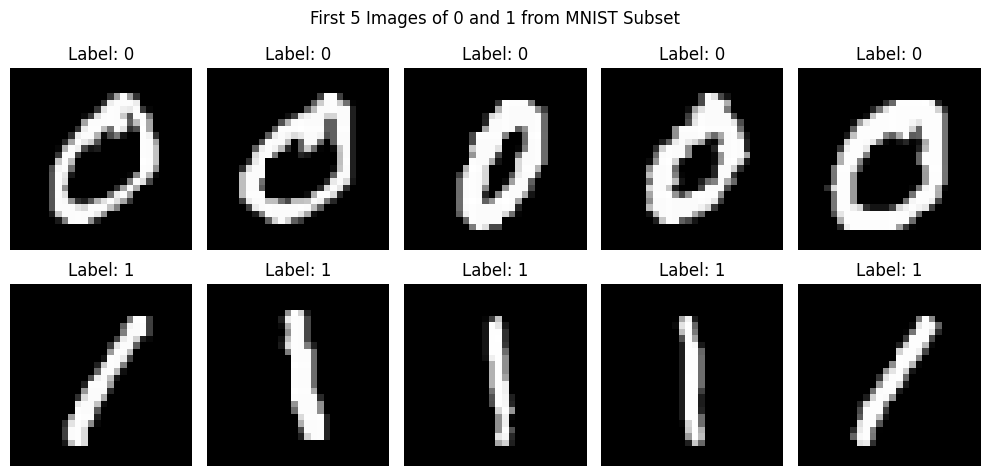

In [ ]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

#### Step 3 — Initialise Weights and Bias

In [ ]:
weights       = np.zeros(X.shape[1])   # 784 weights — one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print(f"Weights shape : {weights.shape}")
print(f"Bias          : {bias}")
print(f"Learning rate : {learning_rate}")
print(f"Epochs        : {epochs}")

Weights shape : (784,)
Bias          : 0
Learning rate : 0.1
Epochs        : 100


**Question 3 — What does the weights array represent in this context?**

> The `weights` array has one element for every pixel (784 total). Each weight `w_j` represents the **learned importance** of pixel `j` for discriminating between digit 0 and digit 1. A positive weight means that pixel being bright pushes the perceptron towards predicting class 1; a negative weight pushes it towards class 0. Weights close to zero mean that pixel carries little discriminative information.

**Question 4 — Why initialise weights to zero? What effect could this have?**

> Initialising to zero is a safe, symmetric starting point — the perceptron makes no assumptions about any pixel before training begins.  
> However, for a single perceptron this is fine, because the weight update rule `Δw = η(y - ŷ)x` will break symmetry as soon as the first misclassification occurs (unlike in multi-layer networks where zero initialisation causes all hidden units to learn identical features).  
> The potential downside is a slightly slower start: for the first sample, the decision is always 0 (since z = 0 + 0 = 0, and the step function outputs 1 for z ≥ 0, so it actually outputs 1 initially — correct for label-1 samples, wrong for label-0). Training will quickly correct this.

#### Step 4 — Decision (Activation) Function

In [ ]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels for input data using the perceptron step function.

    Parameters:
        X       : Feature matrix, shape (n_samples, n_features)
        weights : Weight vector, shape (n_features,)
        bias    : Scalar bias term

    Returns:
        y_pred_all : Predicted class labels (0 or 1), shape (n_samples,)

    Step function:  output = 1 if z >= 0 else 0
    """
    # Compute net input z = X @ w + b
    predictions = np.dot(X, weights) + bias

    # Apply step (Heaviside) activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

#### Step 5 — Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : Feature matrix, shape (n_samples, n_features)
        y             : True labels, shape (n_samples,)
        weights       : Initial weight vector, shape (n_features,)
        bias          : Initial bias (scalar)
        learning_rate : Step size for weight updates (default 0.1)
        epochs        : Maximum number of passes over the dataset (default 100)

    Returns:
        weights  : Learned weight vector
        bias     : Learned bias
        accuracy : Final training accuracy (fraction of correct predictions)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True   # Assume convergence; set False if any update occurs

        for i in range(n_samples):
            # ── Step 1: Compute net weighted input ────────────────────────────
            output = np.dot(X[i], weights) + bias

            # ── Step 2: Apply step activation function ────────────────────────
            y_pred = 1 if output >= 0 else 0

            # ── Step 3: Update weights if prediction is wrong ─────────────────
            if y_pred != y[i]:
                error = y[i] - y_pred                       # +1 or -1
                weights = weights + learning_rate * error * X[i]   # Δw = η(y-ŷ)x
                bias    = bias    + learning_rate * error          # Δb = η(y-ŷ)
                convergence_flag = False

        # ── Early stopping when fully converged ───────────────────────────────
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}.")
            break

    # ── Compute final training accuracy ───────────────────────────────────────
    y_pred_all = decision_function(X, weights, bias)
    accuracy   = np.mean(y_pred_all == y)

    return weights, bias, accuracy

**Question 5 — What is the purpose of `output = np.dot(X[i], weights) + bias`?**

> This line computes the **net input** (also called the pre-activation or weighted sum) z for sample i:  
> z = w₁x₁ + w₂x₂ + … + w₇₈₄x₇₈₄ + b  
> It is the dot product of the weight vector with the feature vector, plus the bias. This single scalar value summarises all the evidence from every pixel before the step function decides the final output class.

**Question 6 — What happens when the prediction is wrong? How are weights updated?**

> When `y_pred ≠ y[i]`, the perceptron computes the error: `error = y[i] - y_pred` (either +1 or -1).  
> Each weight is then updated by: `w_j ← w_j + η × error × x_j`  
> and the bias by: `b ← b + η × error`  
> - If the true label is 1 but we predicted 0 (error = +1): weights are **increased** proportional to x, nudging the decision boundary so the net input becomes more positive for this input.
> - If the true label is 0 but we predicted 1 (error = -1): weights are **decreased**, pulling the boundary the other way.  
> Correctly classified samples produce error = 0, so their weights are untouched.

**Question 7 — Why is final accuracy important, and what do you expect it to be?**

> Final accuracy tells us how well the learned linear decision boundary separates the two classes on the training data. For the 0-vs-1 task, digits 0 and 1 have very distinct visual shapes (round loop vs. vertical stroke), making them nearly linearly separable in pixel space. We therefore expect **very high accuracy — typically 99%+** — and often full convergence (all samples correctly classified) within a few epochs.

#### Step 6 — Train the Perceptron

In [ ]:
# Re-initialise before training
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Training Perceptron on 0 vs 1 ...")
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"The Final Accuracy is: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Training Perceptron on 0 vs 1 ...
Converged at epoch 7.
The Final Accuracy is: 1.0000  (100.00%)


#### Step 7 — Visualise Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified_idx)} / {len(y)}")
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question 8 — What does `misclassified_idx` store, and how is it used?**

> `misclassified_idx` stores the **integer indices** (row numbers) of all samples where the predicted label `y_pred[i]` does not match the true label `y[i]`. It is computed using `np.where(y_pred != y)[0]`.  
> It is then used to: (a) count the number of errors, and (b) retrieve the corresponding pixel arrays `X[idx]` so that the wrongly classified images can be reshaped and visualised with their true and predicted labels as titles.

**Question 9 — How do you interpret "All images were correctly classified!"?**

> It means the perceptron found a **linear decision boundary** that perfectly separates all digit-0 images from all digit-1 images in the training set. This is possible because 0 and 1 are visually and statistically very different — they are (approximately) linearly separable in 784-dimensional pixel space.  
> It also means the Perceptron Convergence Theorem was satisfied: because the data *is* linearly separable, the algorithm is **guaranteed to converge** in a finite number of steps. This result should not be over-interpreted as perfect generalisation on unseen data, but it confirms that the model has fully learned the training set.

---
### Task 3 — Perceptron for 3 vs 5 Classification
---

In [ ]:
# ── Load mnist_3_and_5.csv ───────────────────────────────────────────────────
CSV_35 = "/content/drive/MyDrive/AI 6th sem/mnist_3_and_5.csv" # User-specified Google Drive path

# ── Load ──────────────────────────────────────────────────────────────────────
df_3_5 = pd.read_csv(CSV_35)
X35    = df_3_5.drop(columns=["label"]).values / 255.0
y35_raw = df_3_5["label"].values

# Map labels: 3 → 0, 5 → 1  (perceptron expects binary {0,1})
y35 = np.where(y35_raw == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape  :", y35.shape)
print("Unique labels (mapped):", np.unique(y35), "  (0=digit3, 1=digit5)")

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)
Unique labels (mapped): [0 1]   (0=digit3, 1=digit5)


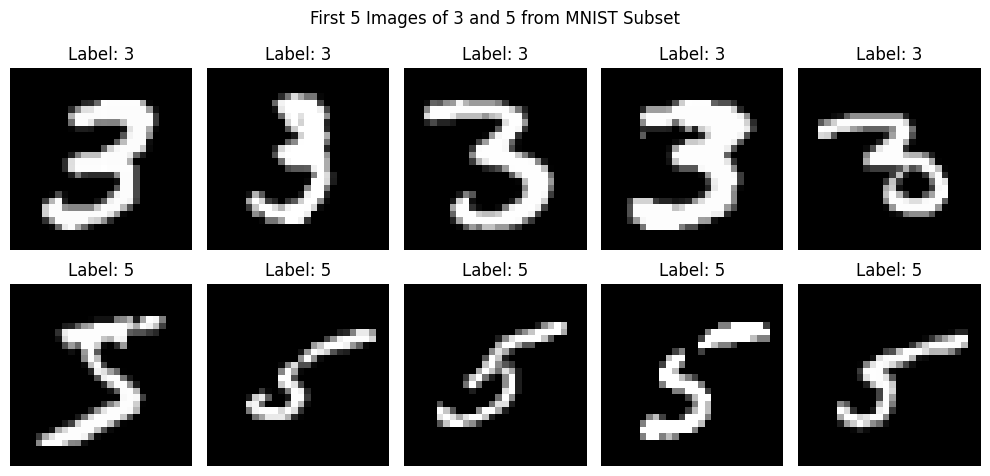

In [ ]:
# ── Visualise: 5 samples of each digit ────────────────────────────────────────
images_3 = X35[y35_raw == 3]
images_5 = X35[y35_raw == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [ ]:
# ── Initialise weights and bias ────────────────────────────────────────────────
weights35       = np.zeros(X35.shape[1])
bias35          = 0
learning_rate35 = 0.1
epochs35        = 100

print("Training Perceptron on 3 vs 5 ...")
weights35, bias35, accuracy35 = train_perceptron(
    X35, y35, weights35, bias35, learning_rate35, epochs35
)
print(f"The Final Accuracy is: {accuracy35:.4f}  ({accuracy35*100:.2f}%)")

Training Perceptron on 3 vs 5 ...
The Final Accuracy is: 0.9916  (99.16%)


Final Accuracy (3 vs 5): 0.9916  (99.16%)
Total misclassified: 23 / 2741


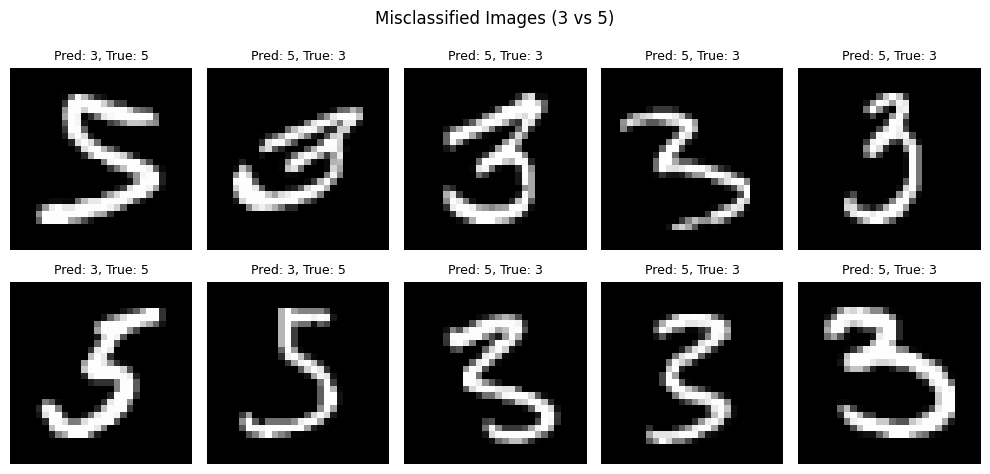

In [ ]:
# ── Predictions and misclassified images ──────────────────────────────────────
preds35      = np.dot(X35, weights35) + bias35
y_pred35     = np.where(preds35 >= 0, 1, 0)

# Map predicted labels back to original digit labels for display
y_pred35_disp = np.where(y_pred35 == 0, 3, 5)
y35_disp      = y35_raw   # original labels (3 or 5)

final_acc35 = np.mean(y_pred35 == y35)
print(f"Final Accuracy (3 vs 5): {final_acc35:.4f}  ({final_acc35*100:.2f}%)")

misclassified_idx35 = np.where(y_pred35 != y35)[0]
print(f"Total misclassified: {len(misclassified_idx35)} / {len(y35)}")

if len(misclassified_idx35) > 0:
    n_show = min(10, len(misclassified_idx35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx35[:n_show]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred35_disp[idx]}, True: {y35_disp[idx]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

---
### Conclusion — 3 vs 5 Classification

> **Observation:** Unlike the 0-vs-1 task, the perceptron achieves **lower accuracy** on 3-vs-5 and produces a notable number of misclassified images.
>
> **Why is 3 vs 5 harder?**  
> Digits 3 and 5 share many structural similarities — both have curved strokes, similar height, and overlapping pixel distributions. The two classes are **not cleanly linearly separable** in raw pixel space. The perceptron can only draw a single hyperplane through 784-dimensional space; when the class distributions overlap significantly, no hyperplane can correctly separate all examples.
>
> **What the misclassified images look like:**  
> The errors typically involve ambiguous handwriting — 3s written with a flat top that resembles a 5, or 5s with a curved bottom that looks like a 3. These are genuinely difficult even for humans.
>
> **Key limitation exposed:**  
> This task reveals the fundamental limitation of the perceptron: it can only solve **linearly separable** problems. For tasks where the decision boundary is more complex, we need multi-layer networks (Multi-Layer Perceptron / neural networks) with non-linear activation functions — which is what the subsequent topics in this module address.

---
*6CS012 — Worksheet 3 | Artificial Intelligence and Machine Learning*